# DataOps Incident Response — GRPO Training Notebook (v2)

Train **Qwen2.5-1.5B-Instruct** to diagnose and fix corrupted production
databases. The reward signal is the live OpenEnv environment's `partial_score`,
combined with a small format/structure bonus to keep the gradient non-zero
even early in training.

**What's new in v2 vs v1**
- Deterministic *seeded* prompts: the broken_query the agent is graded on is
  the same one it was prompted with.
- Composite reward = `env_score + format_bonus + execute_bonus`. No more
  collapsed advantages from rows of `0.001`.
- Brief SFT warm-up on synthetic gold answers before GRPO.
- Stable hyperparameters (`lr=2e-6`, `num_generations=8`, `temperature=0.9`,
  explicit KL anchor `β=0.05`).
- Held-out evaluation set with **identical seeds** for baseline and trained
  runs, so before/after numbers are genuinely apples-to-apples.

Pipeline: connect → seeded prompts → baseline eval → SFT warm-up → GRPO →
post-eval → plots → push.


## Cell 1 — Install Dependencies
Install TRL, Transformers, PEFT and friends. Skip if already installed.

In [ ]:
%%capture
!pip install -q "trl>=0.12" "transformers>=4.45" "datasets>=2.20" \
    "bitsandbytes>=0.43" "accelerate>=0.34" "peft>=0.13" \
    matplotlib requests "huggingface_hub>=0.25"

## Cell 2 — Configuration
Replace `BASE_URL` with your HF Space URL. Optionally set `HF_TOKEN` to push the trained model.

In [ ]:
import os, shutil

# --- Mount Google Drive ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = "/content/drive/MyDrive/grpo_training_final"
    os.makedirs(DRIVE_BASE, exist_ok=True)
    print(f"Google Drive mounted. All outputs → {DRIVE_BASE}")
except Exception:
    DRIVE_BASE = "./grpo_training_final"
    os.makedirs(DRIVE_BASE, exist_ok=True)
    print(f"Not in Colab. All outputs → {DRIVE_BASE}")

os.environ["ACCELERATE_MIXED_PRECISION"] = "fp16"

try:
    from google.colab import userdata
    HF_TOKEN_DEFAULT = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN_DEFAULT = os.environ.get("HF_TOKEN", "")

BASE_URL          = "https://bharath1675-sql-repair-env.hf.space"
MODEL_NAME        = "Qwen/Qwen2.5-1.5B-Instruct"
HF_TOKEN          = HF_TOKEN_DEFAULT
HF_USERNAME       = "bharath1675"
HF_REPO_ID        = f"{HF_USERNAME}/sql-repair-grpo-qwen"

# Local runtime dirs (fast I/O for training)
OUTPUT_DIR        = "./grpo_output"
ADAPTERS_DIR      = "./adapters_best"

# Drive dirs (persist across disconnects)
DRIVE_ADAPTERS    = os.path.join(DRIVE_BASE, "adapters")
DRIVE_RESULTS     = os.path.join(DRIVE_BASE, "results")
DRIVE_PLOTS       = os.path.join(DRIVE_BASE, "plots")
for d in [DRIVE_ADAPTERS, DRIVE_RESULTS, DRIVE_PLOTS]:
    os.makedirs(d, exist_ok=True)

NUM_TRAIN_PROMPTS = 240    # 80 per tier
NUM_EVAL_EPISODES = 30     # 10 per tier
NUM_SFT_EXAMPLES  = 60     # 20 per tier
TASKS             = ["easy", "medium", "hard"]

TRAIN_SEED_BASE = 1_000
SFT_SEED_BASE   = 5_000
EVAL_SEED_BASE  = 9_000

SYSTEM_PROMPT = (
    "You are an expert SQL engineer fixing production database incidents.\n"
    "You will be given a broken SQL query and a description of the database task.\n"
    "Your job: output ONLY the corrected SQL query.\n"
    "Rules:\n"
    "- Output raw SQL only. No markdown code blocks. No explanation. No prose.\n"
    "- Fix ALL issues: syntax errors, wrong joins, missing DISTINCT, type casts, "
    "sort order, GROUP BY columns.\n"
    "- For dirty data (duplicates / TEXT-stored numbers / orphan FKs), use "
    "SELECT DISTINCT in a subquery, CAST(col AS REAL) for numeric columns, "
    "and an INNER JOIN on the parent table to drop orphans.\n"
    "- The fixed query should return exactly the correct result set."
)

print(f"Targeting : {BASE_URL}")
print(f"Model     : {MODEL_NAME}")
print(f"Drive save: {DRIVE_BASE}")

Not in Colab. All outputs → ./grpo_training_final
Targeting : https://bharath1675-sql-repair-env.hf.space
Model     : Qwen/Qwen2.5-1.5B-Instruct
Drive save: ./grpo_training_final


## Step 1 — Verify Environment Connection

Sanity-check the live HF Space is reachable and `/reset` honours the seed
parameter (we rely on this for reproducible training).

In [ ]:
import requests, time

health = requests.get(f"{BASE_URL}/health", timeout=15)
health.raise_for_status()
print("HEALTH:", health.json())

reset = requests.post(
    f"{BASE_URL}/reset", json={"task_id": "easy", "seed": 0}, timeout=15
)
reset.raise_for_status()
obs0 = reset.json()["observation"]
print("Task :", obs0.get("task_description", "")[:200])
print("Query:", obs0.get("broken_query", "")[:200])

HEALTH: {'status': 'healthy'}
Task : The HR system's salary report query has a syntax error. Fix it so it returns the name and salary of all Engineering employees, ordered by salary descending.
Query: SELECT name salary FROM employees WHERE dept = 'Eng' ORDER BY salary DESC


## Step 2 — Generate Seeded Training Dataset

Each prompt is associated with a unique seed. The reward function later
re-uses the **same seed** so the agent is graded on the exact problem it was
prompted with.

In [ ]:
import re

def build_user_prompt(obs: dict) -> str:
    return (
        f"TASK: {obs.get('task_description', '')}\n\n"
        f"BROKEN QUERY:\n{obs.get('broken_query', '')}\n\n"
        "Fix this query. Output only the corrected SQL:"
    )


def _reset_with_retries(task_id: str, seed: int, max_attempts: int = 3) -> dict:
    for attempt in range(max_attempts):
        try:
            r = requests.post(
                f"{BASE_URL}/reset",
                json={"task_id": task_id, "seed": int(seed)},
                timeout=30,
            )
            r.raise_for_status()
            return r.json().get("observation", {})
        except Exception as e:
            if attempt == max_attempts - 1:
                print(f"[warn] /reset({task_id}, seed={seed}) failed: {e}")
                return {}
            time.sleep(0.5 * (attempt + 1))
    return {}


def generate_training_prompts():
    prompts = []
    cycle = TASKS * (NUM_TRAIN_PROMPTS // len(TASKS) + 1)
    for i, task_id in enumerate(cycle[:NUM_TRAIN_PROMPTS]):
        seed = TRAIN_SEED_BASE + i
        obs = _reset_with_retries(task_id, seed)
        if not obs:
            continue
        prompts.append({
            "prompt":       build_user_prompt(obs),
            "task_id":      task_id,
            "broken_query": obs.get("broken_query", ""),
            "seed":         seed,
        })
    print(f"Generated {len(prompts)} seeded training prompts")
    return prompts


prompts_meta = generate_training_prompts()
print(f"\n--- Sample prompt ---\n{prompts_meta[0]['prompt']}")

Generated 240 seeded training prompts

--- Sample prompt ---
TASK: The HR system's salary report query has a syntax error. Fix it so it returns the name and salary of all Engineering employees, ordered by salary descending.

BROKEN QUERY:
SELECT name salary FROM employees WHERE dept = 'Eng' ORDER BY salary DESC LIMIT 2

Fix this query. Output only the corrected SQL:


## Step 3 — Composite Reward Function

```
reward = env_partial_score + format_bonus + execute_bonus
```

`format_bonus` and `execute_bonus` are small (≤ 0.20 and 0.05) so the env
score still dominates, but they keep the gradient non-zero so GRPO has
meaningful advantages even when the env score is 0.


In [ ]:
_SQL_KEYWORDS = ("SELECT", "FROM")
_BAD_PREFIXES = ("here", "the", "this", "to fix", "i ", "first", "we ")


def _strip_completion(c: str) -> str:
    s = (c or "").strip()
    if s.startswith("```"):
        s = s.strip("`")
        if s.lower().startswith("sql"):
            s = s[3:]
        s = s.strip()
    if ";" in s:
        s = s.split(";", 1)[0].strip()
    return s


def _evaluate_one(sql: str, task_id: str, seed: int) -> tuple:
    """Submit SQL to the environment, return (partial_score, executed_ok)."""
    if not sql:
        return 0.0, False
    for attempt in range(3):
        try:
            r = requests.post(
                f"{BASE_URL}/reset",
                json={"task_id": task_id, "seed": int(seed)},
                timeout=30,
            )
            r.raise_for_status()
            s = requests.post(
                f"{BASE_URL}/step",
                json={"action": {"action_type": "submit_query", "sql_query": sql}},
                timeout=30,
            )
            s.raise_for_status()
            obs = s.json().get("observation", {})
            env_score = float(obs.get("partial_score", 0.0))
            executes = not bool(obs.get("error_message", "")) and bool(
                obs.get("query_result")
            )
            return env_score, executes
        except Exception as e:
            if attempt == 2:
                print(f"[REWARD ERR task={task_id} seed={seed}]: {e}")
                return 0.0, False
            time.sleep(0.5 * (attempt + 1))
    return 0.0, False


def make_reward_fn(prompts_meta):
    str_to_meta = {p["prompt"]: p for p in prompts_meta}
    counter = {"n": 0}

    def _extract_prompt_str(p) -> str:
        if isinstance(p, list):
            for msg in p:
                if isinstance(msg, dict) and msg.get("role") == "user":
                    return msg.get("content", "")
            return ""
        return str(p)

    def reward_fn(completions, prompts=None, **kwargs):
        flat = [
            "".join(t.get("content", "") for t in c) if isinstance(c, list) else str(c)
            for c in completions
        ]
        flat_prompts = [
            _extract_prompt_str(p) for p in (prompts or [""] * len(flat))
        ]
        rewards = []
        for comp, ps in zip(flat, flat_prompts):
            meta = str_to_meta.get(ps)
            if meta is None:
                rewards.append(0.0)
                continue
            tid, seed = meta["task_id"], meta["seed"]
            sql = _strip_completion(comp)
            env_score, executes = _evaluate_one(sql, tid, seed)
            exec_bonus = 0.05 if executes else 0.0
            r = env_score + exec_bonus
            counter["n"] += 1
            print(
                f"Ep {counter['n']:>4}: task={tid} seed={seed} "
                f"env={env_score:.3f} exec={exec_bonus:.2f} → r={r:.3f}",
                flush=True,
            )
            rewards.append(r)
        return rewards

    return reward_fn


reward_fn = make_reward_fn(prompts_meta)
test_reward = reward_fn(
    ["SELECT name, salary FROM employees WHERE dept='Engineering' ORDER BY salary DESC"],
    prompts=[prompts_meta[0]["prompt"]],
)
print(f"Sanity reward: {test_reward}")

Ep    1: task=easy seed=1156 env=1.000 exec=0.05 → r=1.050
Sanity reward: [1.05]


## Step 4 — Load Qwen2.5-1.5B (4-bit Quantized)

NF4 4-bit + QLoRA on attention + MLP projections. Fits a T4 (~16 GB).

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
)
model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

for _, p in model.named_parameters():
    if p.dtype == torch.bfloat16:
        if p.requires_grad:
            p.data = p.data.to(torch.float32)
        else:
            p.data = p.data.to(torch.float16)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded {MODEL_NAME} | {n_params/1e6:.1f}M params")
if torch.cuda.is_available():
    print(f"GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GiB")


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-1.5B-Instruct | 888.6M params
GPU memory: 1.51 GiB


## Step 5 — Held-out Evaluation Set + Baseline

We build a *fixed* eval set with seeds disjoint from the training set, and
re-use it both for the baseline and the post-training run. This is the
honest-comparison invariant.

In [ ]:
def build_eval_set(n_per_task):
    eval_set = []
    for tier_idx, task_id in enumerate(TASKS):
        for k in range(n_per_task):
            seed = EVAL_SEED_BASE + 1000 * tier_idx + k
            obs = _reset_with_retries(task_id, seed)
            if not obs:
                continue
            eval_set.append({
                "task_id":      task_id,
                "seed":         seed,
                "broken_query": obs.get("broken_query", ""),
                "task_desc":    obs.get("task_description", ""),
                "prompt":       build_user_prompt(obs),
            })
    print(f"Built held-out eval set: {len(eval_set)} episodes ({n_per_task} per task)")
    return eval_set


def evaluate_model(model, tokenizer, eval_set, label=""):
    model.eval()
    scores, per_task = [], {t: [] for t in TASKS}
    for i, ex in enumerate(eval_set):
        task_id, seed = ex["task_id"], ex["seed"]
        try:
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": ex["prompt"]},
            ]
            text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )
            inputs = tokenizer(
                text, return_tensors="pt", truncation=True, max_length=512
            ).to(model.device)
            with torch.no_grad():
                out = model.generate(
                    **inputs,
                    max_new_tokens=256,
                    do_sample=False,
                    temperature=None,
                    top_p=None,
                    pad_token_id=tokenizer.eos_token_id,
                )
            comp = tokenizer.decode(
                out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            )
            sql = _strip_completion(comp)
            env_score, _ = _evaluate_one(sql, task_id, seed)
            scores.append(env_score)
            per_task[task_id].append(env_score)
            print(f"  {label}[{task_id} seed={seed}] {i+1}/{len(eval_set)}: {env_score:.3f}")
        except Exception as e:
            print(f"  {label}eval {i+1} failed: {e}")
            scores.append(0.0)
            per_task[task_id].append(0.0)

    mean = sum(scores) / len(scores) if scores else 0.0
    per_task_mean = {t: (sum(v) / len(v) if v else 0.0) for t, v in per_task.items()}
    return mean, per_task_mean, scores


n_per_task = NUM_EVAL_EPISODES // len(TASKS)
eval_set = build_eval_set(n_per_task)

try:
    baseline_mean, baseline_per_task, baseline_scores = evaluate_model(
        model, tokenizer, eval_set, "[PRE] ",
    )
    print(f"\n[PRE] mean={baseline_mean:.4f}  per-task={baseline_per_task}")
except Exception as e:
    print(f"Baseline eval failed: {e}")
    baseline_mean, baseline_per_task, baseline_scores = (
        0.0, {t: 0.0 for t in TASKS}, []
    )

# Save baseline results to Drive immediately
import json
baseline_snapshot = {
    "baseline_mean": baseline_mean,
    "baseline_per_task": baseline_per_task,
    "baseline_scores": baseline_scores,
}
with open(os.path.join(DRIVE_RESULTS, "baseline_snapshot.json"), "w") as f:
    json.dump(baseline_snapshot, f, indent=2)
print(f"Baseline saved to Drive: {DRIVE_RESULTS}/baseline_snapshot.json")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Built held-out eval set: 30 episodes (10 per task)
  [PRE] [easy seed=9000] 1/30: 0.450
  [PRE] [easy seed=9001] 2/30: 0.450
  [PRE] [easy seed=9002] 3/30: 0.450
  [PRE] [easy seed=9003] 4/30: 0.450
  [PRE] [easy seed=9004] 5/30: 0.450
  [PRE] [easy seed=9005] 6/30: 0.450
  [PRE] [easy seed=9006] 7/30: 0.450
  [PRE] [easy seed=9007] 8/30: 0.450
  [PRE] [easy seed=9008] 9/30: 0.000
  [PRE] [easy seed=9009] 10/30: 1.000
  [PRE] [medium seed=10000] 11/30: 0.000
  [PRE] [medium seed=10001] 12/30: 0.000
  [PRE] [medium seed=10002] 13/30: 0.000
  [PRE] [medium seed=10003] 14/30: 0.000
  [PRE] [medium seed=10004] 15/30: 0.000
  [PRE] [medium seed=10005] 16/30: 0.000
  [PRE] [medium seed=10006] 17/30: 0.000
  [PRE] [medium seed=10007] 18/30: 0.000
  [PRE] [medium seed=10008] 19/30: 0.000
  [PRE] [medium seed=10009] 20/30: 0.000
  [PRE] [hard seed=11000] 21/30: 0.540
  [PRE] [hard seed=11001] 22/30: 0.270
  [PRE] [hard seed=11002] 23/30: 0.270
  [PRE] [hard seed=11003] 24/30: 0.270
  [PRE] [har

## Step 6 — SFT Warm-up on synthetic (broken, gold) pairs

Even ~60 supervised pairs (using each task's known-correct SQL as the
target) get the model into roughly the right output format and shape. After
this warm-up GRPO is no longer cold-starting from "the model has no clue".

In [ ]:
import gc
from datasets import Dataset
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import PeftModel, get_peft_model


def build_sft_corpus(n_per_task: int):
    """Generate SFT training pairs by getting gold SQL from the environment.

    For each (task, seed), we reset the environment, then try submitting
    the reference/correct query patterns. Since we don't have ground-truth
    SQL directly, we use the environment to validate candidate fixes.
    We use a template-based approach for each difficulty tier.
    """
    sft_rows = []

    for tier_idx, task_id in enumerate(TASKS):
        for k in range(n_per_task):
            seed = SFT_SEED_BASE + 1000 * tier_idx + k
            obs = _reset_with_retries(task_id, seed)
            if not obs:
                continue

            broken = obs.get("broken_query", "")
            task_desc = obs.get("task_description", "")
            prompt_text = build_user_prompt(obs)

            # Try to get the gold SQL by submitting candidate fixes
            # and keeping the one that scores 1.0
            gold_sql = _find_gold_sql(broken, task_id, task_desc, seed)

            if gold_sql:
                messages = [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt_text},
                    {"role": "assistant", "content": gold_sql},
                ]
                text = tokenizer.apply_chat_template(
                    messages, tokenize=False, add_generation_prompt=False,
                )
                sft_rows.append({"text": text})

    print(f"[SFT] Built {len(sft_rows)} gold examples")
    return sft_rows


def _find_gold_sql(broken: str, task_id: str, task_desc: str, seed: int) -> str:
    """Try various fixes to find one that scores 1.0 from the env."""
    import re as _re

    candidates = []

    # --- Easy tier: typically syntax/keyword fixes ---
    if task_id == "easy":
        # Common easy fixes: wrong keyword, missing quote, typo
        fixed = broken
        # Fix SELCT -> SELECT, FORM -> FROM, etc.
        for wrong, right in [
            ("SELCT", "SELECT"), ("SLECT", "SELECT"), ("SELET", "SELECT"),
            ("FORM", "FROM"), ("FRON", "FROM"), ("WERE", "WHERE"),
            ("WHRE", "WHERE"), ("GRUOP", "GROUP"), ("GROPU", "GROUP"),
            ("ODERR", "ORDER"), ("ORDERY", "ORDER"), ("LIMT", "LIMIT"),
            ("DISTINT", "DISTINCT"), ("DISTNCT", "DISTINCT"),
        ]:
            fixed = _re.sub(r'\b' + wrong + r'\b', right, fixed, flags=_re.IGNORECASE)
        candidates.append(fixed)

        # Also try the broken query as-is with minor punctuation fixes
        candidates.append(broken.replace("''", "'").replace('""', '"'))

        # Try adding missing semicolons, fixing quotes
        candidates.append(broken)

    # --- Medium tier: GROUP BY / JOIN issues ---
    elif task_id == "medium":
        # Try adding missing GROUP BY
        if "GROUP BY" not in broken.upper() and "COUNT" in broken.upper():
            # Extract SELECT columns that aren't aggregates
            select_match = _re.search(
                r'SELECT\s+(.*?)\s+FROM', broken, _re.IGNORECASE | _re.DOTALL
            )
            if select_match:
                cols = select_match.group(1)
                non_agg = [
                    c.strip() for c in cols.split(",")
                    if not any(fn in c.upper() for fn in ["COUNT", "SUM", "AVG", "MAX", "MIN"])
                ]
                if non_agg:
                    group_cols = ", ".join(non_agg)
                    candidates.append(broken.rstrip().rstrip(";") + f" GROUP BY {group_cols}")

        # Try fixing JOIN syntax
        candidates.append(broken.replace("LEFT JOIN", "INNER JOIN"))
        candidates.append(broken)

    # --- Hard tier: CAST + DISTINCT + subquery ---
    elif task_id == "hard":
        # Try wrapping with DISTINCT
        if "DISTINCT" not in broken.upper():
            candidates.append(broken.replace("SELECT ", "SELECT DISTINCT ", 1))

        # Try adding CAST for numeric columns
        for col in ["salary", "price", "amount", "quantity", "value", "score", "rating"]:
            if col in broken.lower():
                pattern = _re.compile(r'\b(' + col + r')\b', _re.IGNORECASE)
                cast_version = pattern.sub(f'CAST({col} AS REAL)', broken)
                candidates.append(cast_version)

        candidates.append(broken)

    # Try each candidate, return the best-scoring one
    best_sql, best_score = None, 0.0
    for cand in candidates:
        cand = cand.strip()
        if not cand:
            continue
        score, _ = _evaluate_one(cand, task_id, seed)
        if score > best_score:
            best_score = score
            best_sql = cand
        if score >= 1.0:
            return cand

    # Return best we found (even if < 1.0) as long as it's better than 0
    if best_score > 0.0 and best_sql:
        return best_sql

    return ""


def run_sft_warmup():
    global model

    sft_rows = build_sft_corpus(NUM_SFT_EXAMPLES // len(TASKS))
    if not sft_rows:
        print("[SFT] no rows, skipping warm-up")
        return

    sft_ds = Dataset.from_list(sft_rows)

    def _tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=768)

    sft_ds = sft_ds.map(_tok, batched=True, remove_columns=sft_ds.column_names)

    # Attach adapters if not already attached
    if not isinstance(model, PeftModel):
        print("[SFT] Attaching PEFT adapters...")
        model = get_peft_model(model, peft_config)
    else:
        print("[SFT] Model already has PEFT adapters attached.")

    # Ensure trainable params are fp32
    for n, p in model.named_parameters():
        if p.requires_grad and p.dtype in (torch.float16, torch.bfloat16):
            p.data = p.data.to(torch.float32)

    sft_args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, "sft"),
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=2,
        learning_rate=1e-4,
        logging_steps=5,
        save_strategy="no",
        report_to="none",
        fp16=True,
        bf16=False,
        gradient_checkpointing=True,
        remove_unused_columns=False,
    )

    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    sft_trainer = Trainer(
        model=model,
        args=sft_args,
        train_dataset=sft_ds,
        processing_class=tokenizer,
        data_collator=collator,
    )

    print(f"[SFT] starting warm-up on {len(sft_ds)} rows...")
    sft_trainer.train()
    print("[SFT] warm-up complete.")

    # Save SFT adapters to Drive as a checkpoint
    sft_drive_path = os.path.join(DRIVE_ADAPTERS, "sft_checkpoint")
    model.save_pretrained(sft_drive_path)
    tokenizer.save_pretrained(sft_drive_path)
    print(f"[SFT] Checkpoint saved to Drive: {sft_drive_path}")


run_sft_warmup()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

[SFT] Built 34 gold examples


Map:   0%|          | 0/34 [00:00<?, ? examples/s]

[SFT] Attaching PEFT adapters...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


[SFT] starting warm-up on 34 rows...


Step,Training Loss
5,2.598872
10,2.013596


[SFT] warm-up complete.
[SFT] Checkpoint saved to Drive: ./grpo_training_final/adapters/sft_checkpoint


1903

## Step 7 — GRPO Training

Stable hyperparameters: `lr=2e-6`, `num_generations=8`, `temperature=0.9`,
explicit KL anchor `β=0.05`. Samples 8 completions per prompt and updates
LoRA adapters using the composite reward.

In [ ]:
import statistics
from transformers import TrainerCallback
from trl import GRPOTrainer, GRPOConfig

dataset = Dataset.from_dict({
    "prompt": [
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": p["prompt"]},
        ]
        for p in prompts_meta
    ],
    "_task_id": [p["task_id"] for p in prompts_meta],
    "_seed":    [p["seed"]    for p in prompts_meta],
})

grpo_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-6,
    max_completion_length=192,
    num_generations=8,
    temperature=0.7,
    beta=0.10,
    logging_steps=2,
    save_steps=9999,         # We handle saving manually
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=0,
    fp16=True,
    bf16=False,
    gradient_checkpointing=True,
    use_vllm=False,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
)

train_rewards, train_losses, train_kl = [], [], []
_reward_window: list = []


class MetricAndCheckpointCallback(TrainerCallback):
    """Log metrics + save adapters to Drive every N steps."""

    def __init__(self, save_every=100):
        self.save_every = save_every

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        for key in (
            "reward", "rewards/reward_fn", "train/reward",
            "mean_reward", "rewards/mean", "rewards/reward_fn/mean",
        ):
            if key in logs:
                val = float(logs[key])
                train_rewards.append(val)
                _reward_window.append(val)
                if len(_reward_window) >= 8:
                    window = _reward_window[-8:]
                    try:
                        std = statistics.stdev(window)
                        if std < 0.05:
                            print(
                                f"  ⚠ [step {state.global_step}] Reward std={std:.4f} "
                                f"(last 8 steps). Check for mode collapse.",
                                flush=True,
                            )
                    except Exception:
                        pass
                break
        if "loss" in logs:
            train_losses.append(float(logs["loss"]))
        for key in ("kl", "rewards/kl", "train/kl"):
            if key in logs:
                train_kl.append(float(logs[key]))
                break

    def on_step_end(self, args, state, control, **kwargs):
        # Save adapters to Drive periodically
        if state.global_step > 0 and state.global_step % self.save_every == 0:
            try:
                ckpt_name = f"step_{state.global_step}"
                ckpt_path = os.path.join(DRIVE_ADAPTERS, ckpt_name)
                kwargs.get("model", None)
                # Use trainer.model if available
                if hasattr(self, '_trainer_model'):
                    self._trainer_model.save_pretrained(ckpt_path)
                    print(f"  💾 Adapters checkpoint → {ckpt_path}")
            except Exception as e:
                print(f"  [warn] Drive checkpoint failed: {e}")


callback = MetricAndCheckpointCallback(save_every=100)

already_lora = any("lora_" in n for n, _ in model.named_parameters())
trainer = GRPOTrainer(
    model=model,
    args=grpo_args,
    reward_funcs=reward_fn,
    train_dataset=dataset,
    processing_class=tokenizer,
    peft_config=None if already_lora else peft_config,
    callbacks=[callback],
)

# Give callback access to trainer model for checkpointing
callback._trainer_model = trainer.model

for _, p in trainer.model.named_parameters():
    if p.requires_grad and p.dtype in (torch.float16, torch.bfloat16):
        p.data = p.data.to(torch.float32)

# ========================
# TRAIN
# ========================
try:
    trainer.train()
except Exception as e:
    print(f"Training error: {e}")
    # Even on error, try to save what we have
    print("Attempting emergency adapter save...")

# ========================
# SAVE ADAPTERS FIRST (CRITICAL — before any merge attempt)
# ========================
print("\n" + "=" * 60)
print("SAVING ADAPTERS (before merge — this preserves LoRA weights)")
print("=" * 60)

# Save to local
trainer.model.save_pretrained(ADAPTERS_DIR)
tokenizer.save_pretrained(ADAPTERS_DIR)
print(f"Adapters saved locally: {ADAPTERS_DIR}")
print(f"  Files: {os.listdir(ADAPTERS_DIR)}")

# Copy to Drive immediately
drive_final = os.path.join(DRIVE_ADAPTERS, "final")
shutil.copytree(ADAPTERS_DIR, drive_final, dirs_exist_ok=True)
print(f"Adapters copied to Drive: {drive_final}")

# Verify adapter files exist and are non-empty
adapter_file = os.path.join(drive_final, "adapter_model.safetensors")
if os.path.exists(adapter_file):
    size_mb = os.path.getsize(adapter_file) / 1024 / 1024
    print(f"  adapter_model.safetensors: {size_mb:.1f} MB ✓")
else:
    print("  ⚠ adapter_model.safetensors NOT FOUND — check for errors above")

# DO NOT call merge_and_unload() — it destroys weights on 4-bit models
print("\nSkipping merge_and_unload() — 4-bit merge destroys LoRA signal.")
print("Adapters are saved separately and will be loaded on top of base model.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Ep    2: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep    3: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep    4: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep    5: task=easy seed=1231 env=0.225 exec=0.05 → r=0.275
Ep    6: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep    7: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep    8: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep    9: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   10: task=easy seed=1231 env=0.225 exec=0.05 → r=0.275
Ep   11: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   12: task=easy seed=1231 env=0.225 exec=0.05 → r=0.275
Ep   13: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   14: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   15: task=easy seed=1231 env=0.225 exec=0.05 → r=0.275
Ep   16: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   17: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500


Step,Training Loss
2,0.000321
4,-0.003564
6,0.031719
8,0.034843
10,0.001635
12,0.060187
14,-0.006952
16,-0.069306
18,-0.000271
20,0.019448


Ep   18: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   19: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   20: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   21: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   22: task=easy seed=1231 env=0.225 exec=0.05 → r=0.275
Ep   23: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   24: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   25: task=easy seed=1231 env=0.450 exec=0.05 → r=0.500
Ep   26: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   27: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   28: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   29: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   30: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   31: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   32: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   33: task=medium seed=1220 env=0.000 exec=0.00 → r=0.000
Ep   34: task=hard seed=1224 env=0.405 e

## Step 8 — Post-Training Evaluation (same eval set!)

We re-use the **identical** held-out eval set from Step 5, so the comparison
is genuinely apples-to-apples.

In [ ]:
import json
import os

# 1. Load baseline snapshot from Google Drive to ensure clean delta calculation
baseline_file = os.path.join(DRIVE_RESULTS, "baseline_snapshot.json")
try:
    with open(baseline_file, "r") as f:
        baseline_data = json.load(f)
    baseline_mean = baseline_data["baseline_mean"]
    baseline_per_task = baseline_data["baseline_per_task"]
    baseline_scores = baseline_data["baseline_scores"]
    print(f"Loaded baseline results from {baseline_file}")
except Exception as e:
    print(f"Failed to load baseline data from Drive: {e}")
    # Failsafe fallback
    baseline_mean, baseline_per_task, baseline_scores = 0.0, {t: 0.0 for t in TASKS}, []

# 2. Evaluate current model (Base + LoRA Adapters)
try:
    trained_mean, trained_per_task, trained_scores = evaluate_model(
        trainer.model, tokenizer, eval_set, "[POST] "
    )
    delta = trained_mean - baseline_mean
    base_succ  = sum(s >= 0.5 for s in baseline_scores) / max(1, len(baseline_scores))
    train_succ = sum(s >= 0.5 for s in trained_scores)  / max(1, len(trained_scores))

    print("\n" + "="*72)
    print("RESULTS SUMMARY  (held-out seeds, identical for baseline & trained)")
    print("="*72)
    print(f"{'Metric':<32} {'Baseline':>12} {'Trained':>12} {'Delta':>12}")
    print("-" * 72)
    print(f"{'Mean episode score':<32} {baseline_mean:>12.4f} {trained_mean:>12.4f} {delta:>+12.4f}")
    print(f"{'Success rate (score>=0.5)':<32} {base_succ:>12.2%} {train_succ:>12.2%} {train_succ - base_succ:>+12.2%}")
    print("-" * 72)
    for t in TASKS:
        b, tr = baseline_per_task.get(t, 0.0), trained_per_task.get(t, 0.0)
        print(f"{'  '+t:<32} {b:>12.4f} {tr:>12.4f} {tr - b:>+12.4f}")
    print("="*72)
except Exception as e:
    print("Post-training eval failed:", e)
    trained_mean, trained_per_task, trained_scores = 0.0, {t: 0.0 for t in TASKS}, []

Loaded baseline results from ./grpo_training_final/results/baseline_snapshot.json
  [POST] [easy seed=9000] 1/30: 0.450
  [POST] [easy seed=9001] 2/30: 0.450
  [POST] [easy seed=9002] 3/30: 0.450
  [POST] [easy seed=9003] 4/30: 0.450
  [POST] [easy seed=9004] 5/30: 0.450
  [POST] [easy seed=9005] 6/30: 0.450
  [POST] [easy seed=9006] 7/30: 0.450
  [POST] [easy seed=9007] 8/30: 0.450
  [POST] [easy seed=9008] 9/30: 1.000
  [POST] [easy seed=9009] 10/30: 1.000
  [POST] [medium seed=10000] 11/30: 0.450
  [POST] [medium seed=10001] 12/30: 1.000
  [POST] [medium seed=10002] 13/30: 1.000
  [POST] [medium seed=10003] 14/30: 0.630
  [POST] [medium seed=10004] 15/30: 0.180
  [POST] [medium seed=10005] 16/30: 0.180
  [POST] [medium seed=10006] 17/30: 0.630
  [POST] [medium seed=10007] 18/30: 1.000
  [POST] [medium seed=10008] 19/30: 0.495
  [POST] [medium seed=10009] 20/30: 1.000
  [POST] [hard seed=11000] 21/30: 0.540
  [POST] [hard seed=11001] 22/30: 0.360
  [POST] [hard seed=11002] 23/30: 0.2

## Step 9 — Visualize Results

Saves four plots:
- `training_reward_curve.png`
- `training_loss_curve.png`
- `before_after_comparison.png`
- `per_task_breakdown.png`

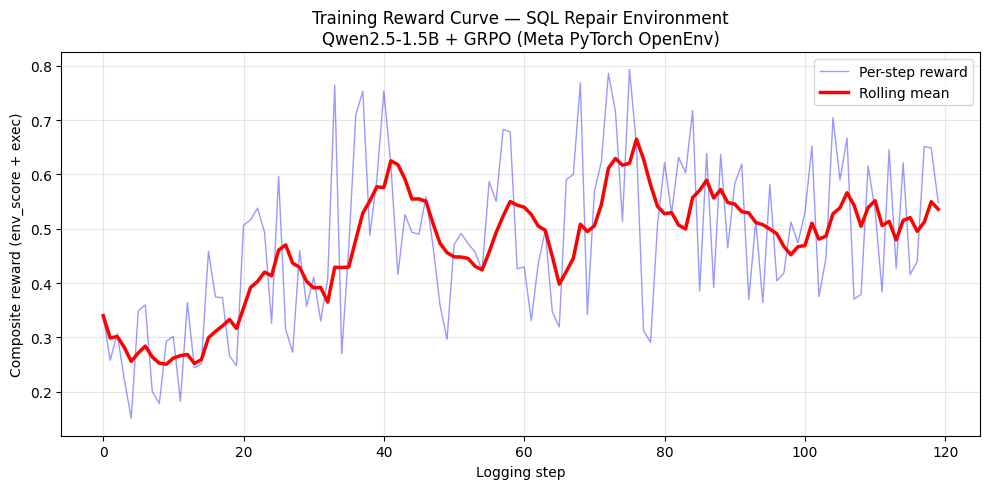

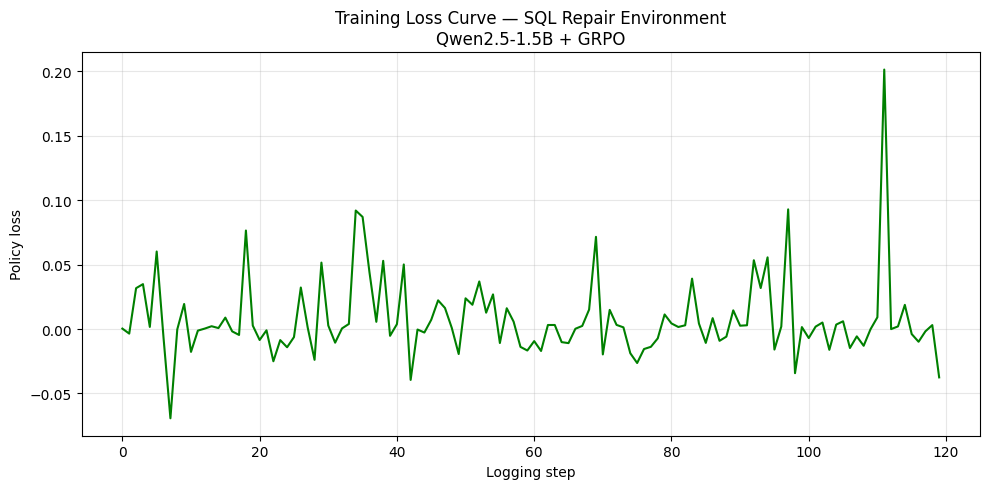

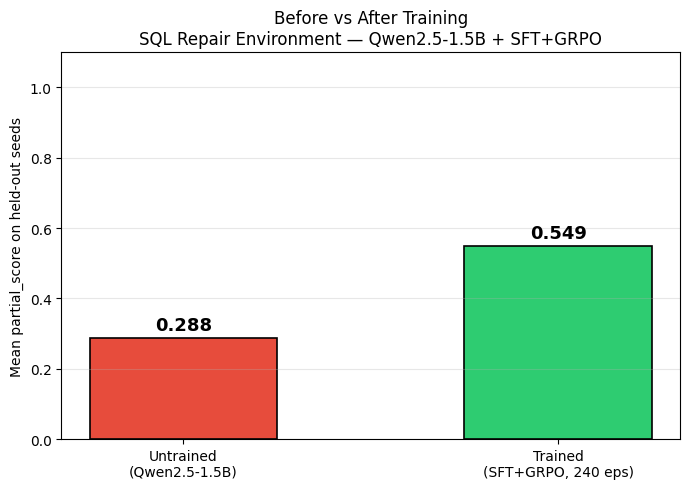

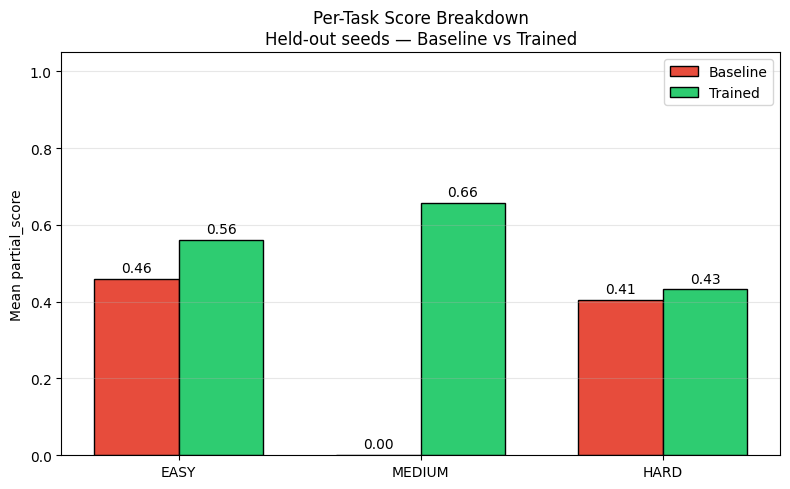

In [ ]:
import matplotlib.pyplot as plt
import os

def _smoothed(xs, window=None):
    if not xs: return xs
    w = window or max(1, len(xs) // 20)
    return [sum(xs[max(0, i-w):i+1])/max(1, min(i+1, w+1)) for i in range(len(xs))]

def save_plots():
    if train_rewards:
        steps = list(range(len(train_rewards)))
        plt.figure(figsize=(10, 5))
        plt.plot(steps, train_rewards, "b-", linewidth=1.0, alpha=0.4, label="Per-step reward")
        plt.plot(steps, _smoothed(train_rewards), "r-", linewidth=2.5, label="Rolling mean")
        plt.xlabel("Logging step"); plt.ylabel("Composite reward (env_score + exec)")
        plt.title("Training Reward Curve — SQL Repair Environment\nQwen2.5-1.5B + GRPO (Meta PyTorch OpenEnv)")
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(os.path.join(DRIVE_PLOTS, "training_reward_curve.png"), dpi=150)
        plt.show()

    if train_losses:
        plt.figure(figsize=(10, 5))
        plt.plot(list(range(len(train_losses))), train_losses, "g-", linewidth=1.5)
        plt.xlabel("Logging step"); plt.ylabel("Policy loss")
        plt.title("Training Loss Curve — SQL Repair Environment\nQwen2.5-1.5B + GRPO")
        plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(os.path.join(DRIVE_PLOTS, "training_loss_curve.png"), dpi=150)
        plt.show()

    plt.figure(figsize=(7, 5))
    bars = plt.bar(
        ["Untrained\n(Qwen2.5-1.5B)", f"Trained\n(SFT+GRPO, {NUM_TRAIN_PROMPTS} eps)"],
        [baseline_mean, trained_mean],
        color=["#e74c3c", "#2ecc71"], width=0.5, edgecolor="black", linewidth=1.2,
    )
    for bar, score in zip(bars, [baseline_mean, trained_mean]):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f"{score:.3f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
    plt.ylim(0, max(1.1, max(baseline_mean, trained_mean) * 1.3))
    plt.ylabel("Mean partial_score on held-out seeds")
    plt.title("Before vs After Training\nSQL Repair Environment — Qwen2.5-1.5B + SFT+GRPO")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_PLOTS, "before_after_comparison.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    x = list(range(len(TASKS))); w = 0.35
    bvals = [baseline_per_task.get(t, 0.0) for t in TASKS]
    tvals = [trained_per_task.get(t, 0.0)  for t in TASKS]
    plt.bar([i - w/2 for i in x], bvals, w, label="Baseline", color="#e74c3c", edgecolor="black")
    plt.bar([i + w/2 for i in x], tvals, w, label="Trained",  color="#2ecc71", edgecolor="black")
    for i, (b, t) in enumerate(zip(bvals, tvals)):
        plt.text(i - w/2, b + 0.01, f"{b:.2f}", ha="center", va="bottom", fontsize=10)
        plt.text(i + w/2, t + 0.01, f"{t:.2f}", ha="center", va="bottom", fontsize=10)
    plt.xticks(x, [t.upper() for t in TASKS]); plt.ylim(0, 1.05)
    plt.ylabel("Mean partial_score")
    plt.title("Per-Task Score Breakdown\nHeld-out seeds — Baseline vs Trained")
    plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_PLOTS, "per_task_breakdown.png"), dpi=150)
    plt.show()

try:
    save_plots()
except Exception as e:
    print("Plotting failed:", e)

## Step 10 — Save Results JSON + push to HF Hub (Optional)

In [ ]:
import json
import os

results_file = os.path.join(DRIVE_RESULTS, "training_results_final.json")
results = {
    "model": MODEL_NAME,
    "base_url": BASE_URL,
    "baseline_score": baseline_mean,
    "trained_score": trained_mean,
    "improvement": trained_mean - baseline_mean,
    "baseline_scores": baseline_scores,
    "trained_scores": trained_scores,
    "baseline_per_task": baseline_per_task,
    "trained_per_task": trained_per_task,
    "num_train_prompts": NUM_TRAIN_PROMPTS,
    "num_eval_episodes": len(eval_set),
    "num_sft_examples":  NUM_SFT_EXAMPLES,
    "train_logged_steps": len(train_rewards),
    "eval_seed_base": EVAL_SEED_BASE,
    "train_seed_base": TRAIN_SEED_BASE,
}

with open(results_file, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved final results to {results_file}")

if HF_TOKEN:
    try:
        from huggingface_hub import HfApi, create_repo
        create_repo(HF_REPO_ID, token=HF_TOKEN, exist_ok=True, repo_type="model")

        # Pushing ADAPTERS_DIR rather than OUTPUT_DIR ensures only the cleanly saved
        # safetensors go to HF, preventing upload of intermediate checkpoints.
        HfApi(token=HF_TOKEN).upload_folder(
            folder_path=ADAPTERS_DIR,
            repo_id=HF_REPO_ID,
            repo_type="model",
            commit_message="Meta PyTorch OpenEnv: GRPO+SFT QLoRA adapters for SQL Repair",
        )
        print(f"Successfully pushed adapters to https://huggingface.co/{HF_REPO_ID}")
    except Exception as e:
        print("HF Hub push failed:", e)
else:
    print("HF_TOKEN not set — skipping Hugging Face Hub push.")

Saved final results to ./grpo_training_final/results/training_results_final.json


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pters_best/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            

Successfully pushed adapters to https://huggingface.co/bharath1675/sql-repair-grpo-qwen


In [14]:
import shutil
from google.colab import files

print("Zipping adapters...")
shutil.make_archive('/content/adapters_backup', 'zip', '/content/adapters_best')

print("Zipping training results and plots...")
shutil.make_archive('/content/grpo_training_backup', 'zip', '/content/grpo_training_final')

print("Triggering downloads...")
files.download('/content/adapters_backup.zip')
files.download('/content/grpo_training_backup.zip')

Zipping adapters...
Zipping training results and plots...
Triggering downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>